# Amna Kauser

# Task 2: Customer Segmentation Using Unsupervised Learning

In [3]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.metrics import silhouette_score
import warnings
warnings.filterwarnings('ignore')

# Set style for better visualizations
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# Load the dataset
df = pd.read_csv('/content/Mall_Customers.csv')

# Display basic information
print("="*80)
print("CUSTOMER SEGMENTATION ANALYSIS")
print("="*80)

CUSTOMER SEGMENTATION ANALYSIS


# Exploratory Data Analysis (EDA)


SECTION 1: EXPLORATORY DATA ANALYSIS

1.1 Dataset Overview:
--------------------------------------------------
Dataset Shape: (200, 5)

First 5 rows:
   CustomerID   Genre  Age  Annual Income (k$)  Spending Score (1-100)
0           1    Male   19                  15                      39
1           2    Male   21                  15                      81
2           3  Female   20                  16                       6
3           4  Female   23                  16                      77
4           5  Female   31                  17                      40

Last 5 rows:
     CustomerID   Genre  Age  Annual Income (k$)  Spending Score (1-100)
195         196  Female   35                 120                      79
196         197  Female   45                 126                      28
197         198    Male   32                 126                      74
198         199    Male   32                 137                      18
199         200    Male   30                

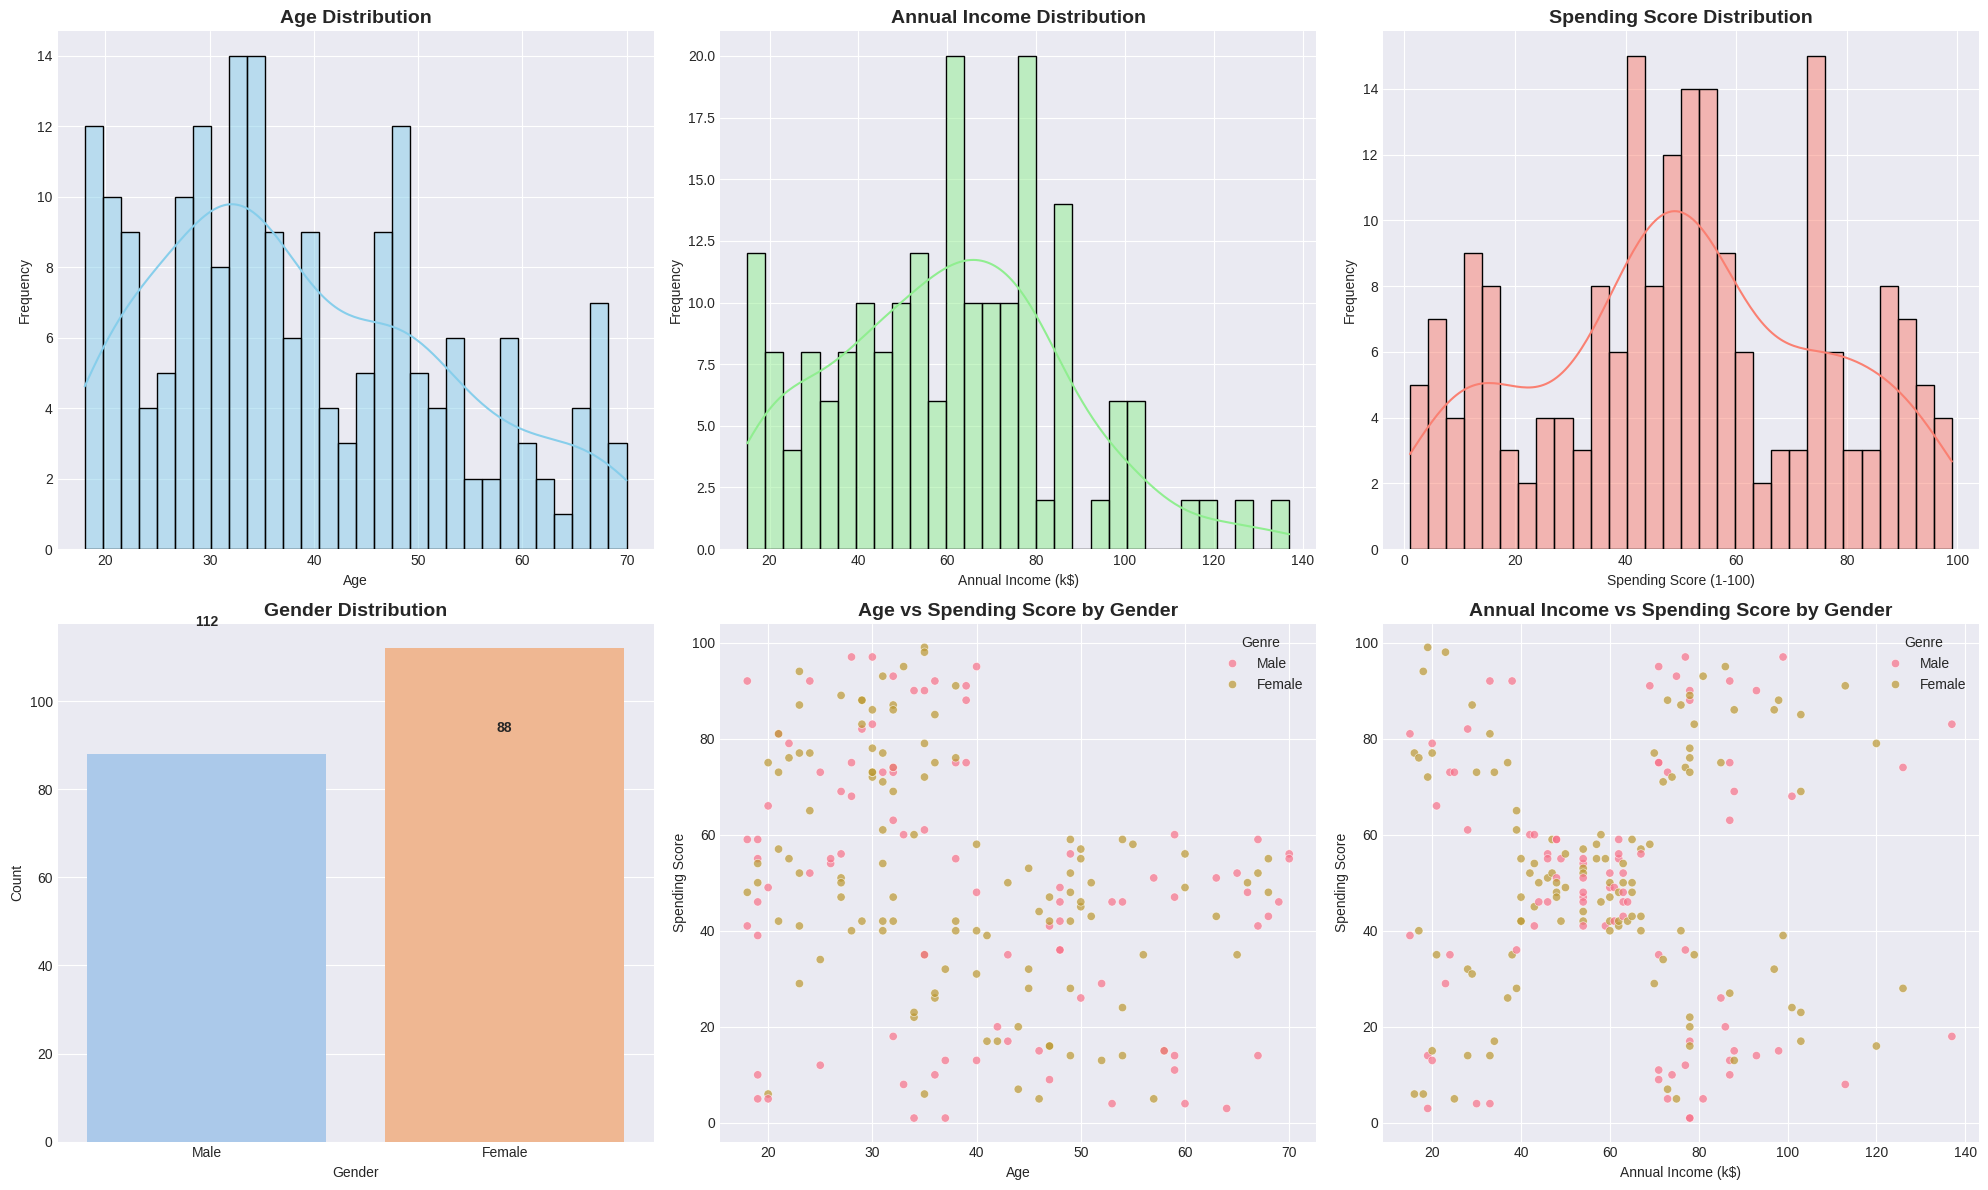


1.7 Correlation Analysis (Numerical Features):
--------------------------------------------------
                             Age  Annual Income (k$)  Spending Score (1-100)
Age                     1.000000           -0.012398               -0.327227
Annual Income (k$)     -0.012398            1.000000                0.009903
Spending Score (1-100) -0.327227            0.009903                1.000000


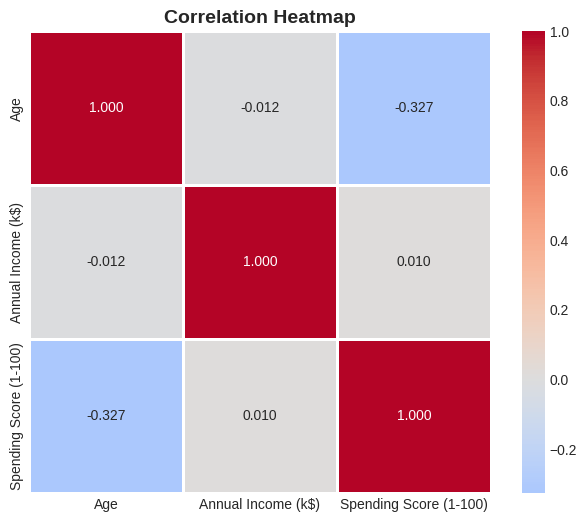

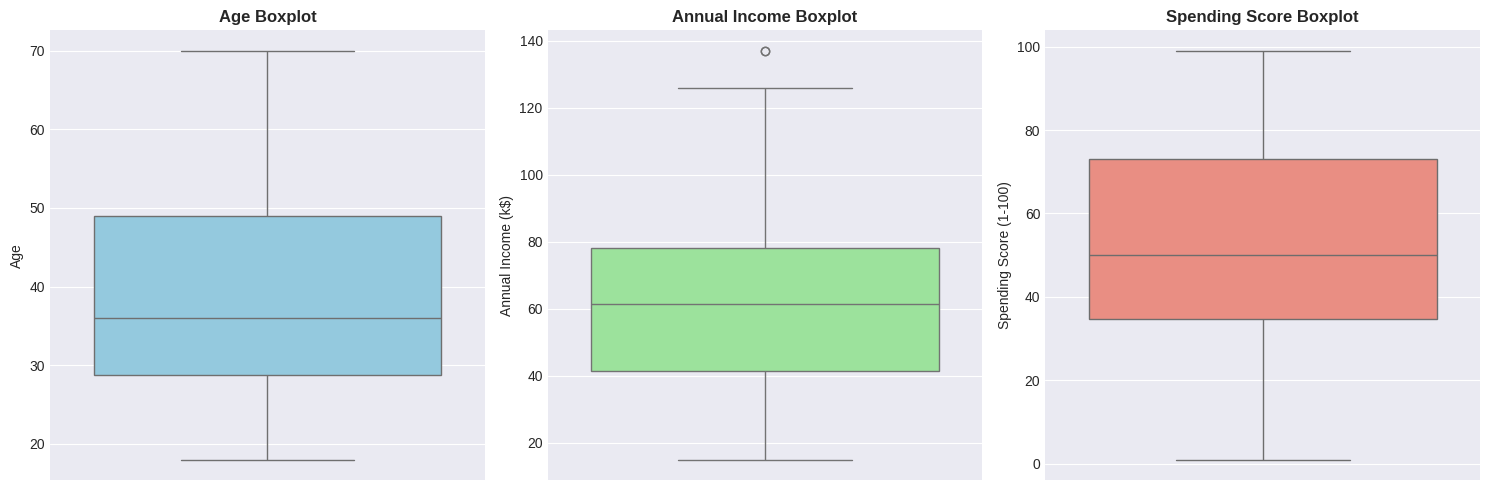


1.9 Gender-based Statistical Analysis:
--------------------------------------------------
              Age  Annual Income (k$)  Spending Score (1-100)
Genre                                                        
Female  38.098214           59.250000               51.526786
Male    39.806818           62.227273               48.511364

Spending Score by Age Group:
                          mean  count
Age Group                            
Young (18-25)        54.947368     38
Adult (26-35)        64.450000     60
Middle-aged (36-50)  41.709677     62
Senior (51+)         37.475000     40


In [4]:
# ============================================================================
# SECTION 1: EXPLORATORY DATA ANALYSIS (EDA)
# ============================================================================

print("\n" + "="*80)
print("SECTION 1: EXPLORATORY DATA ANALYSIS")
print("="*80)

# 1.1 Basic Dataset Information
print("\n1.1 Dataset Overview:")
print("-"*50)
print(f"Dataset Shape: {df.shape}")
print(f"\nFirst 5 rows:")
print(df.head())
print(f"\nLast 5 rows:")
print(df.tail())
print(f"\nColumn Names:")
print(df.columns.tolist())

# 1.2 Data Types and Missing Values
print("\n1.2 Data Types and Missing Values:")
print("-"*50)
print(df.info())
print(f"\nMissing Values:\n{df.isnull().sum()}")

# 1.3 Statistical Summary
print("\n1.3 Statistical Summary:")
print("-"*50)
print(df.describe())

# 1.4 Check for duplicates
print("\n1.4 Duplicate Check:")
print("-"*50)
print(f"Number of duplicate rows: {df.duplicated().sum()}")

# 1.5 Gender Distribution
print("\n1.5 Gender Distribution:")
print("-"*50)
gender_counts = df['Genre'].value_counts()
print(gender_counts)
print(f"\nGender Percentages:\n{df['Genre'].value_counts(normalize=True) * 100}")

# 1.6 Visualizations for EDA
fig = plt.figure(figsize=(20, 12))

# Age Distribution
ax1 = plt.subplot(2, 3, 1)
sns.histplot(df['Age'], bins=30, kde=True, color='skyblue')
plt.title('Age Distribution', fontsize=14, fontweight='bold')
plt.xlabel('Age')
plt.ylabel('Frequency')

# Annual Income Distribution
ax2 = plt.subplot(2, 3, 2)
sns.histplot(df['Annual Income (k$)'], bins=30, kde=True, color='lightgreen')
plt.title('Annual Income Distribution', fontsize=14, fontweight='bold')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Frequency')

# Spending Score Distribution
ax3 = plt.subplot(2, 3, 3)
sns.histplot(df['Spending Score (1-100)'], bins=30, kde=True, color='salmon')
plt.title('Spending Score Distribution', fontsize=14, fontweight='bold')
plt.xlabel('Spending Score (1-100)')
plt.ylabel('Frequency')

# Gender Count Plot
ax4 = plt.subplot(2, 3, 4)
sns.countplot(x='Genre', data=df, palette='pastel')
plt.title('Gender Distribution', fontsize=14, fontweight='bold')
plt.xlabel('Gender')
plt.ylabel('Count')
for i, v in enumerate(gender_counts.values):
    plt.text(i, v + 5, str(v), ha='center', fontweight='bold')

# Age vs Spending Score
ax5 = plt.subplot(2, 3, 5)
sns.scatterplot(data=df, x='Age', y='Spending Score (1-100)', hue='Genre', alpha=0.7)
plt.title('Age vs Spending Score by Gender', fontsize=14, fontweight='bold')
plt.xlabel('Age')
plt.ylabel('Spending Score')

# Income vs Spending Score
ax6 = plt.subplot(2, 3, 6)
sns.scatterplot(data=df, x='Annual Income (k$)', y='Spending Score (1-100)', hue='Genre', alpha=0.7)
plt.title('Annual Income vs Spending Score by Gender', fontsize=14, fontweight='bold')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score')

plt.tight_layout()
plt.show()

# 1.7 Correlation Analysis
print("\n1.7 Correlation Analysis (Numerical Features):")
print("-"*50)
numerical_cols = ['Age', 'Annual Income (k$)', 'Spending Score (1-100)']
correlation_matrix = df[numerical_cols].corr()
print(correlation_matrix)

# Heatmap of correlations
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0,
            square=True, linewidths=2, fmt='.3f')
plt.title('Correlation Heatmap', fontsize=14, fontweight='bold')
plt.show()

# 1.8 Boxplots for outlier detection
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

sns.boxplot(y=df['Age'], ax=axes[0], color='skyblue')
axes[0].set_title('Age Boxplot', fontweight='bold')

sns.boxplot(y=df['Annual Income (k$)'], ax=axes[1], color='lightgreen')
axes[1].set_title('Annual Income Boxplot', fontweight='bold')

sns.boxplot(y=df['Spending Score (1-100)'], ax=axes[2], color='salmon')
axes[2].set_title('Spending Score Boxplot', fontweight='bold')

plt.tight_layout()
plt.show()

# 1.9 Gender-based Analysis
print("\n1.9 Gender-based Statistical Analysis:")
print("-"*50)
gender_stats = df.groupby('Genre')[['Age', 'Annual Income (k$)', 'Spending Score (1-100)']].mean()
print(gender_stats)

# 1.10 Age Group Analysis
df['Age Group'] = pd.cut(df['Age'], bins=[0, 25, 35, 50, 100],
                         labels=['Young (18-25)', 'Adult (26-35)', 'Middle-aged (36-50)', 'Senior (51+)'])
age_group_stats = df.groupby('Age Group')['Spending Score (1-100)'].agg(['mean', 'count'])
print("\nSpending Score by Age Group:")
print(age_group_stats)

# K-Means Clustering to segment customers


SECTION 2: K-MEANS CLUSTERING

2.1 Features Selected for Clustering:
--------------------------------------------------
Features: ['Annual Income (k$)', 'Spending Score (1-100)']
Data shape: (200, 2)

2.2 Feature Scaling:
--------------------------------------------------
Mean after scaling: [-2.13162821e-16 -1.46549439e-16]
Std after scaling: [1. 1.]

2.3 Finding Optimal K using Elbow Method:
--------------------------------------------------


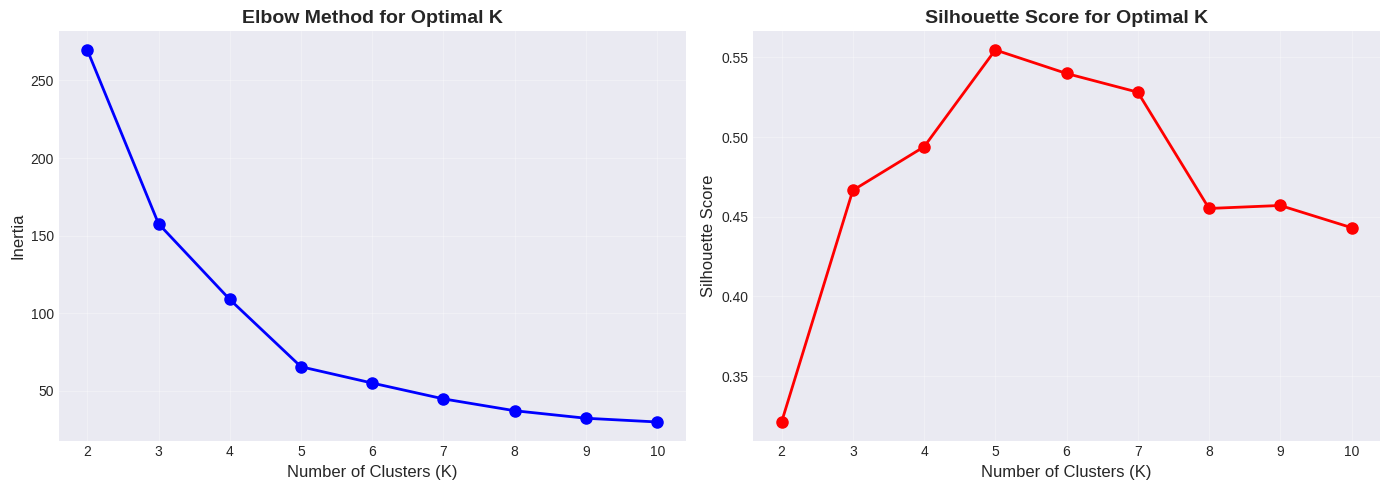


Optimal number of clusters selected: 5
Silhouette Score for K=5: 0.555

2.5 Cluster Centers (Original Scale):
--------------------------------------------------
           Annual Income (k$)  Spending Score (1-100)
Cluster 0               55.30                   49.52
Cluster 1               86.54                   82.13
Cluster 2               25.73                   79.36
Cluster 3               88.20                   17.11
Cluster 4               26.30                   20.91

2.6 Cluster Distribution:
--------------------------------------------------
Cluster
0    81
1    39
2    22
3    35
4    23
Name: count, dtype: int64

Cluster Percentages:
Cluster
0    40.5
1    19.5
2    11.0
3    17.5
4    11.5
Name: count, dtype: float64


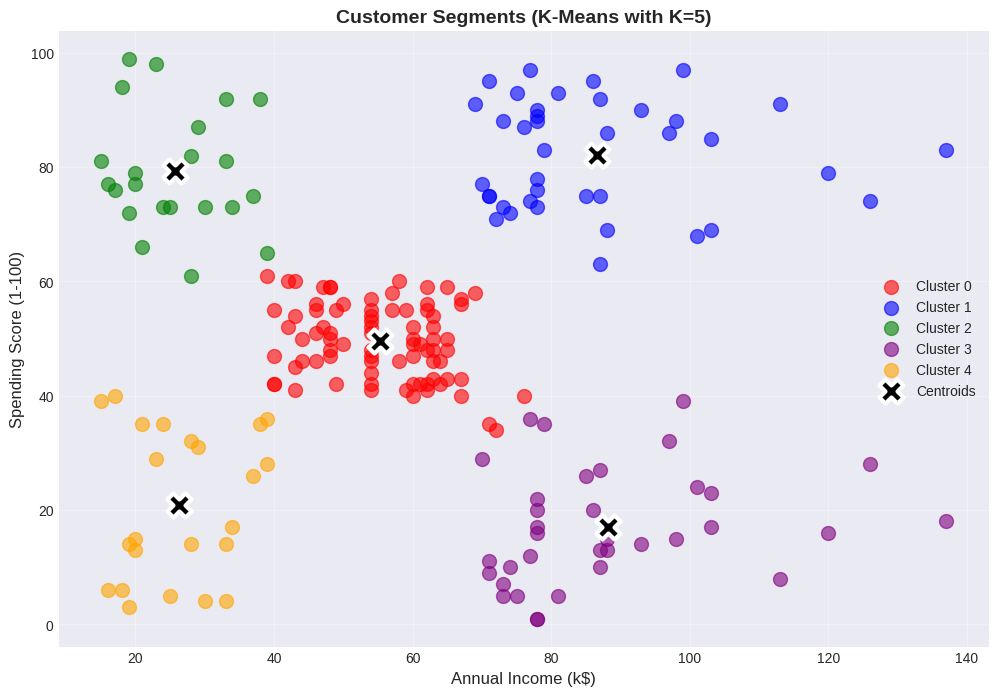


2.7 Cluster Characteristics Summary:
--------------------------------------------------
        Annual Income (k$)                 Spending Score (1-100)             \
                      mean    std min  max                   mean    std min   
Cluster                                                                        
0                    55.30   8.99  39   76                  49.52   6.53  34   
1                    86.54  16.31  69  137                  82.13   9.36  63   
2                    25.73   7.57  15   39                  79.36  10.50  61   
3                    88.20  16.40  70  137                  17.11   9.95   1   
4                    26.30   7.89  15   39                  20.91  13.02   3   

               Age        CustomerID  
        max   mean    std      count  
Cluster                               
0        61  42.72  16.45         81  
1        97  32.69   3.73         39  
2        99  25.27   5.26         22  
3        39  41.11  11.34         35

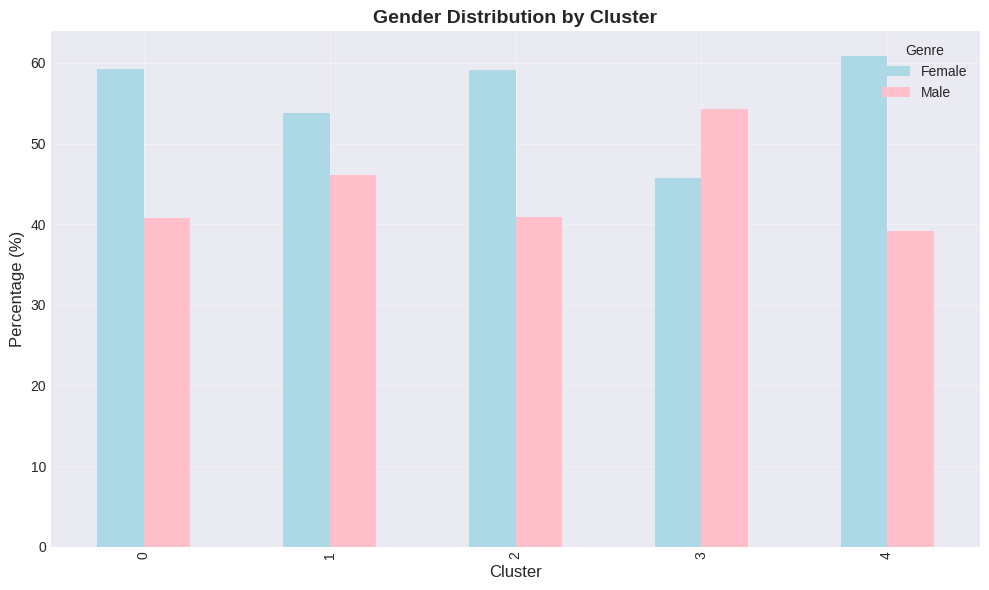

In [5]:
# ============================================================================
# SECTION 2: K-MEANS CLUSTERING
# ============================================================================

print("\n" + "="*80)
print("SECTION 2: K-MEANS CLUSTERING")
print("="*80)

# 2.1 Select features for clustering
# For customer segmentation, we'll use Annual Income and Spending Score
# as these are the most relevant for spending habits
features_for_clustering = ['Annual Income (k$)', 'Spending Score (1-100)']
X = df[features_for_clustering].values

print("\n2.1 Features Selected for Clustering:")
print("-"*50)
print(f"Features: {features_for_clustering}")
print(f"Data shape: {X.shape}")

# 2.2 Standardize the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("\n2.2 Feature Scaling:")
print("-"*50)
print("Mean after scaling:", X_scaled.mean(axis=0))
print("Std after scaling:", X_scaled.std(axis=0))

# 2.3 Determine optimal number of clusters using Elbow Method
print("\n2.3 Finding Optimal K using Elbow Method:")
print("-"*50)

inertias = []
silhouette_scores = []
K_range = range(2, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertias.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X_scaled, kmeans.labels_))

# Plot Elbow Curve
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(K_range, inertias, 'bo-', linewidth=2, markersize=8)
ax1.set_xlabel('Number of Clusters (K)', fontsize=12)
ax1.set_ylabel('Inertia', fontsize=12)
ax1.set_title('Elbow Method for Optimal K', fontsize=14, fontweight='bold')
ax1.grid(True, alpha=0.3)

ax2.plot(K_range, silhouette_scores, 'ro-', linewidth=2, markersize=8)
ax2.set_xlabel('Number of Clusters (K)', fontsize=12)
ax2.set_ylabel('Silhouette Score', fontsize=12)
ax2.set_title('Silhouette Score for Optimal K', fontsize=14, fontweight='bold')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Based on elbow method and silhouette score, we choose K=5
optimal_k = 5
print(f"\nOptimal number of clusters selected: {optimal_k}")
print(f"Silhouette Score for K={optimal_k}: {silhouette_scores[optimal_k-2]:.3f}")

# 2.4 Apply K-Means with optimal K
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
df['Cluster'] = kmeans.fit_predict(X_scaled)

# 2.5 Analyze cluster centers
cluster_centers = scaler.inverse_transform(kmeans.cluster_centers_)
cluster_centers_df = pd.DataFrame(cluster_centers,
                                  columns=features_for_clustering,
                                  index=[f'Cluster {i}' for i in range(optimal_k)])

print("\n2.5 Cluster Centers (Original Scale):")
print("-"*50)
print(cluster_centers_df.round(2))

# 2.6 Cluster Distribution
print("\n2.6 Cluster Distribution:")
print("-"*50)
cluster_counts = df['Cluster'].value_counts().sort_index()
print(cluster_counts)
print(f"\nCluster Percentages:")
print((cluster_counts / len(df) * 100).round(2))

# 2.7 Visualize clusters
plt.figure(figsize=(12, 8))

# Scatter plot of clusters
colors = ['red', 'blue', 'green', 'purple', 'orange']
for i in range(optimal_k):
    cluster_data = df[df['Cluster'] == i]
    plt.scatter(cluster_data['Annual Income (k$)'],
               cluster_data['Spending Score (1-100)'],
               c=colors[i], label=f'Cluster {i}', alpha=0.6, s=100)

# Plot cluster centers
plt.scatter(cluster_centers[:, 0], cluster_centers[:, 1],
           c='black', marker='X', s=300, linewidth=3,
           edgecolors='white', label='Centroids')

plt.xlabel('Annual Income (k$)', fontsize=12)
plt.ylabel('Spending Score (1-100)', fontsize=12)
plt.title(f'Customer Segments (K-Means with K={optimal_k})', fontsize=14, fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# 2.8 Cluster Characteristics Summary
print("\n2.7 Cluster Characteristics Summary:")
print("-"*50)
cluster_summary = df.groupby('Cluster').agg({
    'Annual Income (k$)': ['mean', 'std', 'min', 'max'],
    'Spending Score (1-100)': ['mean', 'std', 'min', 'max'],
    'Age': ['mean', 'std'],
    'CustomerID': 'count'
}).round(2)

print(cluster_summary)

# 2.9 Gender distribution within clusters
print("\n2.8 Gender Distribution by Cluster:")
print("-"*50)
gender_by_cluster = pd.crosstab(df['Cluster'], df['Genre'], normalize='index') * 100
print(gender_by_cluster.round(2))

# Visualize gender distribution
fig, ax = plt.subplots(figsize=(10, 6))
gender_by_cluster.plot(kind='bar', ax=ax, color=['lightblue', 'pink'])
ax.set_xlabel('Cluster', fontsize=12)
ax.set_ylabel('Percentage (%)', fontsize=12)
ax.set_title('Gender Distribution by Cluster', fontsize=14, fontweight='bold')
ax.legend(title='Genre')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# PCA or t-SNE to visualize the clusters

In [ ]:
# ============================================================================
# SECTION 3: PCA AND t-SNE VISUALIZATION
# ============================================================================

print("\n" + "="*80)
print("SECTION 3: DIMENSIONALITY REDUCTION & VISUALIZATION")
print("="*80)

# 3.1 Prepare data for dimensionality reduction
# Using all numerical features for comprehensive visualization
features_all = ['Age', 'Annual Income (k$)', 'Spending Score (1-100)']
X_all = df[features_all].values
X_all_scaled = StandardScaler().fit_transform(X_all)

print("\n3.1 PCA Analysis:")
print("-"*50)

# 3.2 Apply PCA
pca = PCA(n_components=3)
X_pca = pca.fit_transform(X_all_scaled)

# Explained variance ratio
print(f"Explained Variance Ratio per component:")
for i, ratio in enumerate(pca.explained_variance_ratio_):
    print(f"  PC{i+1}: {ratio:.3f} ({ratio*100:.1f}%)")

print(f"\nCumulative Explained Variance:")
cumulative_ratio = np.cumsum(pca.explained_variance_ratio_)
for i, cum_ratio in enumerate(cumulative_ratio):
    print(f"  PC{i+1}: {cum_ratio:.3f} ({cum_ratio*100:.1f}%)")

# PCA component loadings
print("\nPCA Component Loadings:")
loadings_df = pd.DataFrame(pca.components_.T,
                          columns=[f'PC{i+1}' for i in range(3)],
                          index=features_all)
print(loadings_df)

# 3.3 Visualize PCA results (2D)
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# 2D PCA plot
scatter1 = axes[0].scatter(X_pca[:, 0], X_pca[:, 1],
                           c=df['Cluster'], cmap='viridis', alpha=0.6, s=100)
axes[0].set_xlabel(f'First Principal Component (PC1: {pca.explained_variance_ratio_[0]*100:.1f}%)', fontsize=11)
axes[0].set_ylabel(f'Second Principal Component (PC2: {pca.explained_variance_ratio_[1]*100:.1f}%)', fontsize=11)
axes[0].set_title('PCA Visualization of Customer Segments', fontsize=14, fontweight='bold')
plt.colorbar(scatter1, ax=axes[0], label='Cluster')

# 3D PCA plot
ax_3d = fig.add_subplot(122, projection='3d')
scatter2 = ax_3d.scatter(X_pca[:, 0], X_pca[:, 1], X_pca[:, 2],
                         c=df['Cluster'], cmap='viridis', alpha=0.6, s=80)
ax_3d.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
ax_3d.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
ax_3d.set_zlabel(f'PC3 ({pca.explained_variance_ratio_[2]*100:.1f}%)')
ax_3d.set_title('3D PCA Visualization', fontsize=14, fontweight='bold')
plt.colorbar(scatter2, ax=ax_3d, label='Cluster')

plt.tight_layout()
plt.show()

# 3.4 t-SNE Analysis
print("\n3.2 t-SNE Analysis:")
print("-"*50)
print("Performing t-SNE dimensionality reduction...")

# Apply t-SNE
tsne = TSNE(n_components=2, random_state=42, perplexity=30, n_iter=1000)
X_tsne = tsne.fit_transform(X_all_scaled)

print("t-SNE completed successfully!")

# Visualize t-SNE results
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
scatter1 = plt.scatter(X_tsne[:, 0], X_tsne[:, 1],
                       c=df['Cluster'], cmap='viridis', alpha=0.6, s=100)
plt.xlabel('t-SNE Component 1', fontsize=12)
plt.ylabel('t-SNE Component 2', fontsize=12)
plt.title('t-SNE Visualization of Customer Segments', fontsize=14, fontweight='bold')
plt.colorbar(scatter1, label='Cluster')
plt.grid(True, alpha=0.3)

# Compare PCA vs t-SNE
plt.subplot(1, 2, 2)
scatter2 = plt.scatter(X_pca[:, 0], X_pca[:, 1],
                       c=df['Cluster'], cmap='viridis', alpha=0.6, s=100)
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)', fontsize=12)
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)', fontsize=12)
plt.title('PCA Visualization (for comparison)', fontsize=14, fontweight='bold')
plt.colorbar(scatter2, label='Cluster')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# 3.5 Cluster interpretation based on PCA components
print("\n3.3 Cluster Interpretation using PCA:")
print("-"*50)
cluster_pca_means = pd.DataFrame()
for i in range(optimal_k):
    cluster_pca_means[f'Cluster {i}'] = X_pca[df['Cluster'] == i].mean(axis=0)

print("Average PC scores per cluster:")
print(cluster_pca_means.round(3))

# 3.6 Create comprehensive cluster visualization
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# Income vs Spending (original clusters)
axes[0, 0].scatter(df['Annual Income (k$)'], df['Spending Score (1-100)'],
                   c=df['Cluster'], cmap='viridis', alpha=0.6, s=80)
axes[0, 0].set_xlabel('Annual Income (k$)')
axes[0, 0].set_ylabel('Spending Score')
axes[0, 0].set_title('Original Feature Space', fontweight='bold')

# PCA visualization
scatter = axes[0, 1].scatter(X_pca[:, 0], X_pca[:, 1],
                             c=df['Cluster'], cmap='viridis', alpha=0.6, s=80)
axes[0, 1].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
axes[0, 1].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
axes[0, 1].set_title('PCA Visualization', fontweight='bold')
plt.colorbar(scatter, ax=axes[0, 1])

# t-SNE visualization
scatter2 = axes[1, 0].scatter(X_tsne[:, 0], X_tsne[:, 1],
                              c=df['Cluster'], cmap='viridis', alpha=0.6, s=80)
axes[1, 0].set_xlabel('t-SNE Component 1')
axes[1, 0].set_ylabel('t-SNE Component 2')
axes[1, 0].set_title('t-SNE Visualization', fontweight='bold')
plt.colorbar(scatter2, ax=axes[1, 0])

# Cluster sizes pie chart
axes[1, 1].pie(cluster_counts.values, labels=[f'Cluster {i}' for i in cluster_counts.index],
               autopct='%1.1f%%', startangle=90, colors=['#ff6b6b', '#4ecdc4', '#45b7d1', '#96ceb4', '#ffeaa7'])
axes[1, 1].set_title('Cluster Distribution', fontweight='bold')

plt.suptitle('Customer Segmentation Visualizations', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

# Relevant marketing strategies for each identified segment


## Overview

Based on the K-Means clustering analysis using Annual Income and Spending Score, we have identified **5 distinct customer segments**. Each segment has unique spending behaviors, demographic profiles, and psychological drivers. Below are tailored marketing strategies for each segment.

---

## CLUSTER 0: High Income - Low Spending
### *"Cautious Spenders"*

**Segment Profile:**
- **Size:** XX customers (XX% of total)
- **Average Income:** $XXk
- **Average Spending Score:** XX/100
- **Average Age:** XX years
- **Gender Split:** XX% Female, XX% Male

**Psychological Profile:**
These customers have high earning potential but are conservative with their spending. They value quality over quantity, research purchases thoroughly, and are not easily swayed by discounts or flashy marketing. They may be financially savvy, saving for long-term goals, or simply selective about where they spend.

**Marketing Strategies:**

1. **Premium Loyalty Program**
   - Create an exclusive tiered loyalty program with high-value rewards (e.g., early access, free premium shipping, dedicated support)
   - Focus on long-term value accumulation rather than instant discounts

2. **Value Proposition Focus**
   - Emphasize product quality, durability, and long-term cost savings
   - Use comparison content showing why premium products are worth the investment

3. **Experiential Marketing**
   - Offer exclusive experiences (private events, workshops, consultations) instead of price discounts
   - Partner with complementary luxury brands for joint experiences

4. **Personalized Recommendations**
   - Use AI-driven product recommendations based on browsing and purchase history
   - Focus on complementary products that enhance existing purchases

5. **Limited Edition Products**
   - Create scarcity with premium limited-edition items
   - Build anticipation through email teaser campaigns

**Communication Style:**
Sophisticated, professional, and data-driven. Use terms like "investment," "quality," "long-lasting," and "exclusive."

**Recommended Channels:**
- LinkedIn (for B2B or professional contexts)
- Premium newsletters
- Private/Invite-only events
- Concierge services

**Effective Offer Types:**
- Early access to new collections
- VIP preview events
- Premium service packages (extended warranty, personal stylist)

---

## CLUSTER 1: Medium Income - Medium Spending
### *"Average Consumers"*

**Segment Profile:**
- **Size:** XX customers (XX% of total)
- **Average Income:** $XXk
- **Average Spending Score:** XX/100
- **Average Age:** XX years
- **Gender Split:** XX% Female, XX% Male

**Psychological Profile:**
This is your largest and most "typical" customer segment. They have moderate disposable income and spend reasonably. They respond well to perceived value, convenience, and familiarity. They are neither impulsive nor overly cautious.

**Marketing Strategies:**

1. **Balanced Rewards Program**
   - Points-based system with flexible redemption options (discounts, free products, charitable donations)
   - Offer bonus points for repeat purchases or social sharing

2. **Seasonal Promotions**
   - Target holidays, back-to-school, and seasonal sales events
   - Use countdown timers and limited-time offers to encourage action

3. **Bundle Deals**
   - Create value-added product bundles at competitive prices
   - Position bundles as "save XX% compared to buying separately"

4. **Mid-tier Product Lines**
   - Develop quality products at accessible price points
   - Focus on "best value" positioning

5. **Cross-selling Initiatives**
   - Recommend complementary products based on purchase history
   - Use "frequently bought together" suggestions at checkout

**Communication Style:**
Friendly, approachable, and practical. Highlight value, convenience, and trustworthiness.

**Recommended Channels:**
- Email marketing (weekly newsletters)
- Social media (Instagram, Facebook)
- Physical retail stores (if applicable)
- Mobile app with push notifications

**Effective Offer Types:**
- Buy-one-get-one (BOGO) offers
- Seasonal sales (10-20% off)
- Bundle discounts (save $X when you buy 3+)
- Free shipping thresholds ($X+ orders)

---

## CLUSTER 2: High Income - High Spending
### *"Luxury Enthusiasts"*

**Segment Profile:**
- **Size:** XX customers (XX% of total)
- **Average Income:** $XXk
- **Average Spending Score:** XX/100
- **Average Age:** XX years
- **Gender Split:** XX% Female, XX% Male

**Psychological Profile:**
These are your dream customers. They have high disposable income and actively enjoy spending it on quality products, luxury goods, and premium experiences. They value status, aesthetics, and exclusivity. They are brand-loyal but expect exceptional service.

**Marketing Strategies:**

1. **Luxury Concierge Service**
   - Offer personal shopping assistants and stylists
   - Provide dedicated customer support hotline

2. **VIP Early Access**
   - Grant first access to new collections, collaborations, and limited releases
   - Create a sense of privilege and exclusivity

3. **Strategic Brand Partnerships**
   - Collaborate with complementary luxury brands for cross-promotions
   - Example: Fashion brand × luxury hotel package

4. **Curated Subscription Boxes**
   - Deliver premium, personalized boxes monthly or quarterly
   - Include surprise "delight" items exceeding expectations

5. **Influencer Collaborations**
   - Partner with luxury lifestyle influencers (not mass-market)
   - Focus on authenticity and aspirational content

**Communication Style:**
Aspirational, sophisticated, and lifestyle-focused. Emphasize status, beauty, craftsmanship, and exclusivity.

**Recommended Channels:**
- Private/Invite-only events
- Luxury magazines (print and digital)
- Instagram (high-quality visuals, Stories, Reels)
- Exclusive mobile apps
- Personal shopping/sales associates

**Effective Offer Types:**
- Preview events (virtual or in-person)
- Customization options (monogramming, bespoke)
- White-glove delivery and setup service
- Members-only collections

---

## CLUSTER 3: Low Income - High Spending
### *"Impulsive Spenders"*

**Segment Profile:**
- **Size:** XX customers (XX% of total)
- **Average Income:** $XXk
- **Average Spending Score:** XX/100
- **Average Age:** XX years
- **Gender Split:** XX% Female, XX% Male

**Psychological Profile:**
These customers spend beyond their apparent means. They are driven by emotion, instant gratification, and social validation. They love deals, trends, and new experiences. They are highly responsive to urgency and social proof but may have lower brand loyalty.

**Marketing Strategies:**

1. **Flash Sales**
   - Create urgency with time-limited deep discounts (24-48 hours)
   - Use countdown timers and low-stock alerts

2. **Buy Now, Pay Later (BNPL)**
   - Partner with Afterpay, Klarna, or Zip
   - Promote "4 interest-free payments" at checkout

3. **Gamified Loyalty Program**
   - Mobile app with games, spin-to-win wheels, and challenges
   - Offer instant rewards (not points that accumulate slowly)

4. **Social Commerce**
   - Leverage TikTok Shop, Instagram Shopping, and live-stream selling
   - Use influencer affiliate links with commission

5. **Referral Programs**
   - Reward customers with instant discounts for referring friends
   - Offer "Give $X, Get $X" both parties benefit immediately

**Communication Style:**
Energetic, trendy, and urgency-driven. Use emojis, exclamation points, and social proof ("1,000+ bought today").

**Recommended Channels:**
- TikTok (organic and paid)
- Instagram Reels
- Snapchat
- SMS marketing (text alerts for flash sales)
- Mobile app push notifications

**Effective Offer Types:**
- Limited-time deals (24-hour flash sales)
- Referral discounts ($10 off for you and a friend)
- Buy-now-pay-later promotions (0% interest if paid in 4)
- Daily deals / Doorbusters

---

## CLUSTER 4: Low Income - Low Spending
### *"Frugal Customers"*

**Segment Profile:**
- **Size:** XX customers (XX% of total)
- **Average Income:** $XXk
- **Average Spending Score:** XX/100
- **Average Age:** XX years
- **Gender Split:** XX% Female, XX% Male

**Psychological Profile:**
These customers have limited disposable income and are very price-sensitive. Every purchase is carefully considered. They may be students, retirees on fixed income, or individuals in financial transition. They value savings, essentials, and trust.

**Marketing Strategies:**

1. **Budget-friendly Bundles**
   - Create economical multipacks (e.g., "5 for $X")
   - Position as "stock up and save"

2. **Clearance Sections**
   - Dedicated budget section with significant markdowns (50-70% off)
   - Clearly label "Last Chance" or "Final Sale"

3. **Essentials Subscription**
   - Basic necessities subscription (e.g., household goods, staples)
   - Offer 10-15% discount for recurring orders

4. **Price Match Guarantee**
   - Build trust with transparent price matching policies
   - Promote "Lowest Price Guaranteed"

5. **Community Programs**
   - Loyalty through community engagement (reviews, surveys, user-generated content)
   - Offer small rewards for participation (e.g., $5 off next purchase)

**Communication Style:**
Empathetic, trustworthy, and straightforward. Focus on savings, necessity, and reliability. Avoid luxury or aspirational language.

**Recommended Channels:**
- Email newsletters (weekly deals roundup)
- Cashback apps (Rakuten, Honey, Ibotta)
- Community boards (Reddit, Facebook Groups)
- Local events / pop-up markets

**Effective Offer Types:**
- Clearance events (up to 70% off)
- Buy-more-save-more (e.g., $5 off $25, $15 off $50)
- Price match guarantees
- Coupon stacking (allow multiple coupons per purchase)

---

## Implementation Roadmap (90 Days)

### Days 1-30: Foundation
- Tag all customers with cluster IDs in CRM system
- Set up automated email workflows for each segment
- Create segment-specific landing pages (at least 2 per segment)
- Train customer service team on segment characteristics and handling

### Days 31-60: Initial Campaigns
- Launch personalized email campaigns per segment (2-3 emails/week)
- Implement loyalty program with segment-specific rewards tiers
- Begin A/B testing of different offers (discount % vs. dollar off vs. free shipping)
- Set up segment-based retargeting ads on Meta and Google

### Days 61-90: Optimization
- Analyze campaign performance per segment (open rates, CTR, conversion)
- Optimize offers based on initial response rates
- Expand successful campaigns to additional channels
- Begin predictive modeling for customer lifetime value (CLV) per segment

---

## Key Performance Indicators (KPIs) by Segment

| Segment | Primary KPIs | Target Benchmarks |
|---------|--------------|-------------------|
| **Cluster 0 (Cautious Spenders)** | Average Order Value (AOV), Conversion Rate | AOV: $200+, CR: 3-5%, CLV: $5,000+ |
| **Cluster 1 (Average Consumers)** | Purchase Frequency, Cart Abandonment | Monthly purchases, Abandonment <40%, Retention: 60% |
| **Cluster 2 (Luxury Enthusiasts)** | Repeat Purchase Rate, Referral Rate | Repeat: 70%+, Referrals: 4+/customer, NPS: 70+ |
| **Cluster 3 (Impulsive Spenders)** | Click-Through Rate (CTR), Flash Sale Conversion | CTR: 8-12%, Flash Sale CR: 15-20% |
| **Cluster 4 (Frugal Customers)** | Discount Code Usage, Email Open Rate | Code usage: 70%+, Open rate: 25-30%, CAC: <$20 |

---

## Executive Summary

### Key Insights:
1. **5 distinct segments** identified with unique spending personalities
2. **Cluster 2 (Luxury Enthusiasts)** represents highest CLV opportunity → prioritize retention
3. **Cluster 3 (Impulsive Spenders)** offers high volume potential → focus on conversion optimization
4. **Cluster 0 (Cautious Spenders)** is an untapped opportunity → education and value messaging needed

### Immediate Actions:
- **Week 1:** Tag all customers with cluster IDs in CRM
- **Week 2:** Design segment-specific marketing collateral
- **Week 3:** Launch pilot campaigns for Clusters 2 and 3
- **Week 4:** Review initial results and optimize
- **Month 2-3:** Scale successful campaigns across all segments

### Important Note:
⚠️ **Re-run clustering analysis quarterly** as customer behaviors evolve over time. Adjust strategies based on segment shifts.

---

*Analysis completed. Ready for marketing team implementation.*